In [82]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
from pathlib import Path

legend_properties = {'weight': 'bold'}
nus_blue = "#003D7C"
nus_orange = "#EF7C00"

# Nature three colors
nature_orange = "#F16C23"
nature_blue = "#2B6A99"
nature_green = "#1B7C3D"

# Morandi six colors
morandi_blue = "#046586"
morandi_green = "#28A9A1"
morandi_yellow = "#C9A77C"
morandi_orange = "#F4A016"
morandi_pink = "#F6BBC6"
morandi_red = "#E71F19"
morandi_purple = "#B08BEB"

# Others
shallow_grey = "#D3D3D3"


In [83]:
# Folder containing the output files from grun_1.py and srun_1.py.
# Update this path if the scripts are executed in a different working directory.
data_folder = Path(r"/Volumes/T7/data/gst-0112-26/Parallel_Search/Parallel_Search_K_3")
results_folder = data_folder / "Results"
results_folder.mkdir(parents=True, exist_ok=True)

# Aligned with grun_1.py and srun_1.py
K_list = [1, 2, 3, 4, 5, 6, 7, 8]
agent_num_list = np.arange(50, 550, step=50, dtype=int).tolist()


In [84]:
# Load all G/S independent-search DVs.
# Keep the loading code explicit for easy revision.

g_breakthrough_rank_across_K_size = []
s_breakthrough_rank_across_K_size = []
g_diversity_across_K_size = []
s_diversity_across_K_size = []
g_pairwise_diversity_across_K_size = []
s_pairwise_diversity_across_K_size = []

for agent_num in agent_num_list:
    file_path = data_folder / "g_independent_breakthrough_rank_across_K_size_{0}".format(agent_num)
    if not file_path.exists():
        raise FileNotFoundError("Missing file: {0}".format(file_path))
    with open(file_path, "rb") as infile:
        g_breakthrough_rank_across_K_size.append(pickle.load(infile))

for agent_num in agent_num_list:
    file_path = data_folder / "s_independent_breakthrough_rank_across_K_size_{0}".format(agent_num)
    if not file_path.exists():
        raise FileNotFoundError("Missing file: {0}".format(file_path))
    with open(file_path, "rb") as infile:
        s_breakthrough_rank_across_K_size.append(pickle.load(infile))

for agent_num in agent_num_list:
    file_path = data_folder / "g_independent_diversity_across_K_size_{0}".format(agent_num)
    if not file_path.exists():
        raise FileNotFoundError("Missing file: {0}".format(file_path))
    with open(file_path, "rb") as infile:
        g_diversity_across_K_size.append(pickle.load(infile))

for agent_num in agent_num_list:
    file_path = data_folder / "s_independent_diversity_across_K_size_{0}".format(agent_num)
    if not file_path.exists():
        raise FileNotFoundError("Missing file: {0}".format(file_path))
    with open(file_path, "rb") as infile:
        s_diversity_across_K_size.append(pickle.load(infile))

for agent_num in agent_num_list:
    file_path = data_folder / "g_independent_pairwise_diversity_across_K_size_{0}".format(agent_num)
    if not file_path.exists():
        raise FileNotFoundError("Missing file: {0}".format(file_path))
    with open(file_path, "rb") as infile:
        g_pairwise_diversity_across_K_size.append(pickle.load(infile))

for agent_num in agent_num_list:
    file_path = data_folder / "s_independent_pairwise_diversity_across_K_size_{0}".format(agent_num)
    if not file_path.exists():
        raise FileNotFoundError("Missing file: {0}".format(file_path))
    with open(file_path, "rb") as infile:
        s_pairwise_diversity_across_K_size.append(pickle.load(infile))

print("Loaded G breakthrough rank: {0}".format(np.asarray(g_breakthrough_rank_across_K_size).shape))
print("Loaded S breakthrough rank: {0}".format(np.asarray(s_breakthrough_rank_across_K_size).shape))
print("Loaded G diversity: {0}".format(np.asarray(g_diversity_across_K_size).shape))
print("Loaded S diversity: {0}".format(np.asarray(s_diversity_across_K_size).shape))
print("Loaded G pairwise diversity: {0}".format(np.asarray(g_pairwise_diversity_across_K_size).shape))
print("Loaded S pairwise diversity: {0}".format(np.asarray(s_pairwise_diversity_across_K_size).shape))


Loaded G breakthrough rank: (10, 8)
Loaded S breakthrough rank: (10, 8)
Loaded G diversity: (10, 8)
Loaded S diversity: (10, 8)
Loaded G pairwise diversity: (10, 8)
Loaded S pairwise diversity: (10, 8)


## Main figures

Only the three requested figures are kept below. Each cell draws exactly one figure and contains the full plotting code.


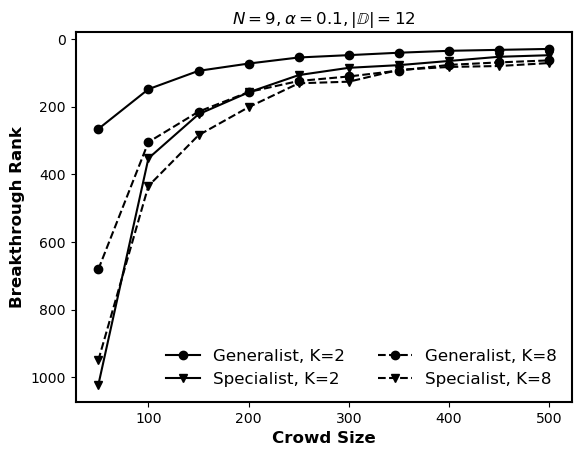

In [85]:
# Breakthrough across Crowd Size
# y is measured by breakthrough rank, with lower rank at the top

g_breakthrough_rank_across_size_K = []
s_breakthrough_rank_across_size_K = []
for index in range(len(K_list)):
    g_breakthrough_rank_across_size = []
    s_breakthrough_rank_across_size = []
    for g_breakthrough_rank, s_breakthrough_rank in zip(g_breakthrough_rank_across_K_size, s_breakthrough_rank_across_K_size):
        g_breakthrough_rank_across_size.append(g_breakthrough_rank[index])
        s_breakthrough_rank_across_size.append(s_breakthrough_rank[index])
    g_breakthrough_rank_across_size_K.append(g_breakthrough_rank_across_size)
    s_breakthrough_rank_across_size_K.append(s_breakthrough_rank_across_size)

x = agent_num_list
fig, ax = plt.subplots()
ax.spines["left"].set_linewidth(1.5)
ax.spines["right"].set_linewidth(1.5)
ax.spines["top"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)
plt.plot(x, g_breakthrough_rank_across_size_K[1], marker='o', linestyle='-', label="Generalist, K=2", color="k")
plt.plot(x, s_breakthrough_rank_across_size_K[1], marker='v', linestyle='-', label="Specialist, K=2", color="k")
plt.plot(x, g_breakthrough_rank_across_size_K[7], marker='o', linestyle='--', label="Generalist, K=8", color="k")
plt.plot(x, s_breakthrough_rank_across_size_K[7], marker='v', linestyle='--', label="Specialist, K=8", color="k")
plt.xlabel('Crowd Size', fontweight='bold', fontsize=12)
plt.ylabel('Breakthrough Rank', fontweight='bold', fontsize=12)
plt.gca().invert_yaxis()
plt.title(r"$N=9, \alpha=0.1, |\mathbb{D}|=12$")
plt.legend(frameon=False, ncol=2, fontsize=12)
# plt.savefig(results_folder / "parallel_search_breakthrough_rank", transparent=True, dpi=300)
plt.show()


Generalist Average Rank: [411.0396875, 193.17312500000003, 129.7546875, 98.9103125, 78.12875, 66.631875, 56.177187499999995, 48.279375, 42.61625, 39.6646875]
Specialist Average Rank: [949.4953125, 410.6596875, 245.30875, 170.1390625, 123.2934375, 102.98625000000001, 87.7840625, 71.8684375, 63.325312499999995, 54.5890625]


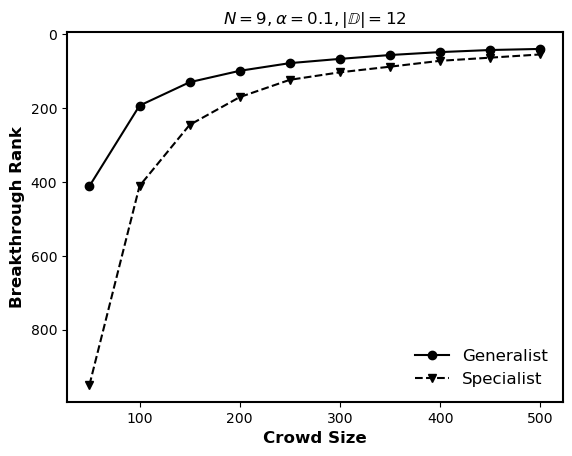

In [86]:
# Breakthrough across Crowd Size
# y is measured by breakthrough rank, with lower rank at the top
# two-line version: average breakthrough rank across K for each crowd type

g_breakthrough_rank_mean_across_K = []
s_breakthrough_rank_mean_across_K = []

for g_breakthrough_rank, s_breakthrough_rank in zip(
    g_breakthrough_rank_across_K_size,
    s_breakthrough_rank_across_K_size
):
    g_breakthrough_rank_mean_across_K.append(np.mean(g_breakthrough_rank))
    s_breakthrough_rank_mean_across_K.append(np.mean(s_breakthrough_rank))

print("Generalist Average Rank:", g_breakthrough_rank_mean_across_K)
print("Specialist Average Rank:", s_breakthrough_rank_mean_across_K)

x = agent_num_list
fig, ax = plt.subplots()

ax.spines["left"].set_linewidth(1.5)
ax.spines["right"].set_linewidth(1.5)
ax.spines["top"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

plt.plot(
    x,
    g_breakthrough_rank_mean_across_K,
    marker="o",
    linestyle="-",
    label="Generalist",
    color="k"
)

plt.plot(
    x,
    s_breakthrough_rank_mean_across_K,
    marker="v",
    linestyle="--",
    label="Specialist",
    color="k"
)

plt.xlabel("Crowd Size", fontweight="bold", fontsize=12)
plt.ylabel("Breakthrough Rank", fontweight="bold", fontsize=12)

# Lower rank means better breakthrough, so put lower values at the top
plt.gca().invert_yaxis()

plt.title(r"$N=9, \alpha=0.1, |\mathbb{D}|=12$")
plt.legend(frameon=False, ncol=1, fontsize=12)

plt.savefig(
    results_folder / "parallel_search_breakthrough_across_size",
    transparent=True,
    dpi=300
)

plt.show()

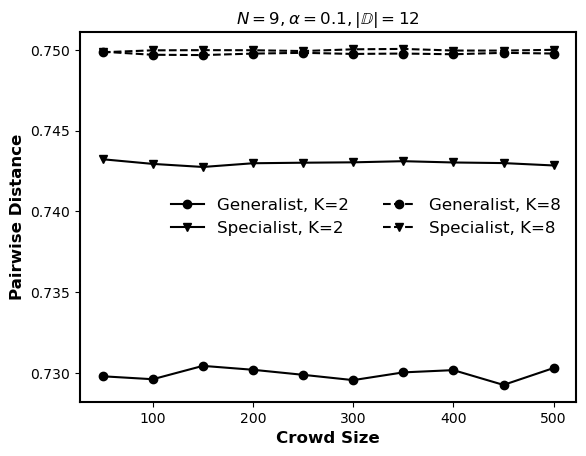

In [87]:
# Diversity across Crowd Size
# y is measured by pairwise distance

g_pairwise_diversity_across_size_K = []
s_pairwise_diversity_across_size_K = []
for index in range(len(K_list)):
    g_pairwise_diversity_across_size = []
    s_pairwise_diversity_across_size = []
    for g_pairwise_diversity, s_pairwise_diversity in zip(g_pairwise_diversity_across_K_size, s_pairwise_diversity_across_K_size):
        g_pairwise_diversity_across_size.append(g_pairwise_diversity[index])
        s_pairwise_diversity_across_size.append(s_pairwise_diversity[index])
    g_pairwise_diversity_across_size_K.append(g_pairwise_diversity_across_size)
    s_pairwise_diversity_across_size_K.append(s_pairwise_diversity_across_size)

x = agent_num_list
fig, ax = plt.subplots()
ax.spines["left"].set_linewidth(1.5)
ax.spines["right"].set_linewidth(1.5)
ax.spines["top"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)
plt.plot(x, g_pairwise_diversity_across_size_K[1], marker='o', linestyle='-', label="Generalist, K=2", color="k")
plt.plot(x, s_pairwise_diversity_across_size_K[1], marker='v', linestyle='-', label="Specialist, K=2", color="k")
plt.plot(x, g_pairwise_diversity_across_size_K[7], marker='o', linestyle='--', label="Generalist, K=8", color="k")
plt.plot(x, s_pairwise_diversity_across_size_K[7], marker='v', linestyle='--', label="Specialist, K=8", color="k")
plt.xlabel('Crowd Size', fontweight='bold', fontsize=12)
plt.ylabel('Pairwise Distance', fontweight='bold', fontsize=12)
plt.title(r"$N=9, \alpha=0.1, |\mathbb{D}|=12$")
plt.legend(frameon=False, ncol=2, fontsize=12)
# plt.savefig(results_folder / "parallel_search_pairwise_diversity", transparent=True, dpi=300)
plt.show()


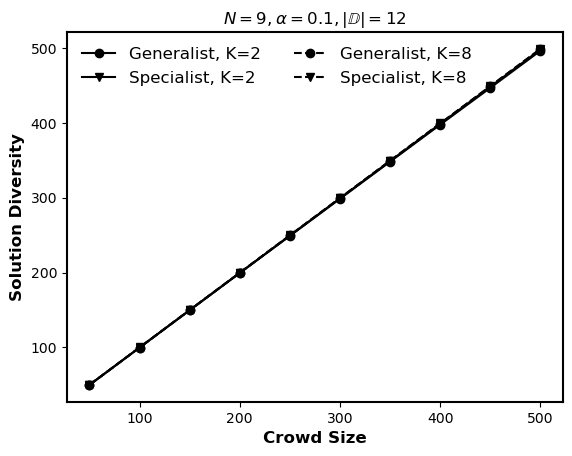

In [88]:
# Diversity across Crowd Size
# y is measured by uniqueness diversity

g_diversity_across_size_K = []
s_diversity_across_size_K = []
for index in range(len(K_list)):
    g_diversity_across_size = []
    s_diversity_across_size = []
    for g_diversity, s_diversity in zip(g_diversity_across_K_size, s_diversity_across_K_size):
        g_diversity_across_size.append(g_diversity[index])
        s_diversity_across_size.append(s_diversity[index])
    g_diversity_across_size_K.append(g_diversity_across_size)
    s_diversity_across_size_K.append(s_diversity_across_size)

x = agent_num_list
fig, ax = plt.subplots()
ax.spines["left"].set_linewidth(1.5)
ax.spines["right"].set_linewidth(1.5)
ax.spines["top"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)
plt.plot(x, g_diversity_across_size_K[1], marker='o', linestyle='-', label="Generalist, K=2", color="k")
plt.plot(x, s_diversity_across_size_K[1], marker='v', linestyle='-', label="Specialist, K=2", color="k")
plt.plot(x, g_diversity_across_size_K[7], marker='o', linestyle='--', label="Generalist, K=8", color="k")
plt.plot(x, s_diversity_across_size_K[7], marker='v', linestyle='--', label="Specialist, K=8", color="k")
plt.xlabel('Crowd Size', fontweight='bold', fontsize=12)
plt.ylabel('Solution Diversity', fontweight='bold', fontsize=12)
plt.title(r"$N=9, \alpha=0.1, |\mathbb{D}|=12$")
plt.legend(frameon=False, ncol=2, fontsize=12)
# plt.savefig(results_folder / "parallel_search_diversity", transparent=True, dpi=300)
plt.show()


Uniqueness: [49.97625, 99.904375, 149.7965625, 199.63421875, 249.42984375, 299.17640625, 348.88687500000003, 398.571875, 448.17703124999997, 497.7571875]


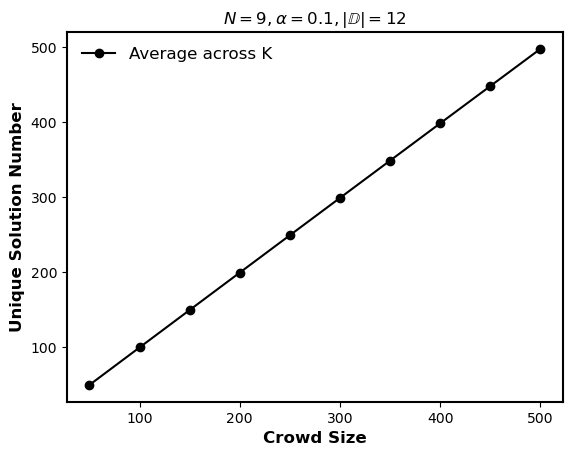

In [92]:
# Diversity across Crowd Size
# y is measured by uniqueness diversity
# one-line version: averaged across K and solver types

g_diversity_mean_across_K = []
s_diversity_mean_across_K = []

for g_diversity, s_diversity in zip(g_diversity_across_K_size, s_diversity_across_K_size):
    g_diversity_mean_across_K.append(np.mean(g_diversity))
    s_diversity_mean_across_K.append(np.mean(s_diversity))

# Average across Generalists and Specialists to produce one single line
diversity_mean_across_K = []
for g_mean, s_mean in zip(g_diversity_mean_across_K, s_diversity_mean_across_K):
    diversity_mean_across_K.append(np.mean([g_mean, s_mean]))
print("Uniqueness:", diversity_mean_across_K)
x = agent_num_list
fig, ax = plt.subplots()

ax.spines["left"].set_linewidth(1.5)
ax.spines["right"].set_linewidth(1.5)
ax.spines["top"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

plt.plot(
    x,
    diversity_mean_across_K,
    marker="o",
    linestyle="-",
    label="Average across K",
    color="k"
)

plt.xlabel("Crowd Size", fontweight="bold", fontsize=12)
plt.ylabel("Unique Solution Number", fontweight="bold", fontsize=12)
plt.title(r"$N=9, \alpha=0.1, |\mathbb{D}|=12$")
plt.legend(frameon=False, ncol=1, fontsize=12)

plt.savefig(
    results_folder / "parallel_search_unique_diversity_across_size",
    transparent=True,
    dpi=300
)
plt.show()

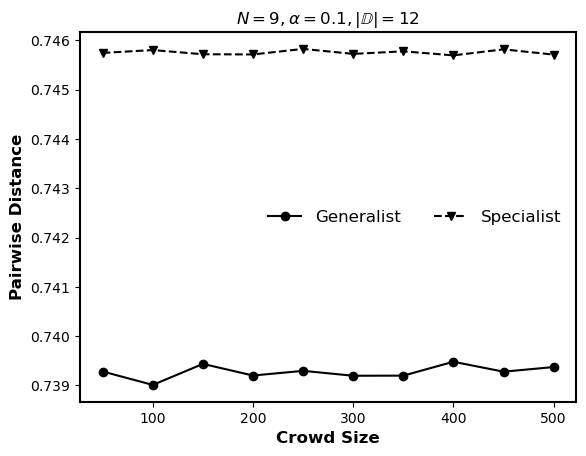

In [90]:
# Diversity across Crowd Size
# y is measured by pairwise distance
# two-line version: average across K for each crowd type

g_pairwise_diversity_mean_across_K = []
s_pairwise_diversity_mean_across_K = []

for g_pairwise_diversity, s_pairwise_diversity in zip(
    g_pairwise_diversity_across_K_size,
    s_pairwise_diversity_across_K_size
):
    g_pairwise_diversity_mean_across_K.append(np.mean(g_pairwise_diversity))
    s_pairwise_diversity_mean_across_K.append(np.mean(s_pairwise_diversity))

x = agent_num_list
fig, ax = plt.subplots()

ax.spines["left"].set_linewidth(1.5)
ax.spines["right"].set_linewidth(1.5)
ax.spines["top"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

plt.plot(
    x,
    g_pairwise_diversity_mean_across_K,
    marker='o',
    linestyle='-',
    label="Generalist",
    color="k"
)
plt.plot(
    x,
    s_pairwise_diversity_mean_across_K,
    marker='v',
    linestyle='--',
    label="Specialist",
    color="k"
)

plt.xlabel('Crowd Size', fontweight='bold', fontsize=12)
plt.ylabel('Pairwise Distance', fontweight='bold', fontsize=12)
plt.title(r"$N=9, \alpha=0.1, |\mathbb{D}|=12$")
plt.legend(frameon=False, ncol=2, fontsize=12)

plt.savefig(
    results_folder / "parallel_search_pairwise_diversity_across_size",
    transparent=True,
    dpi=300
)
plt.show()

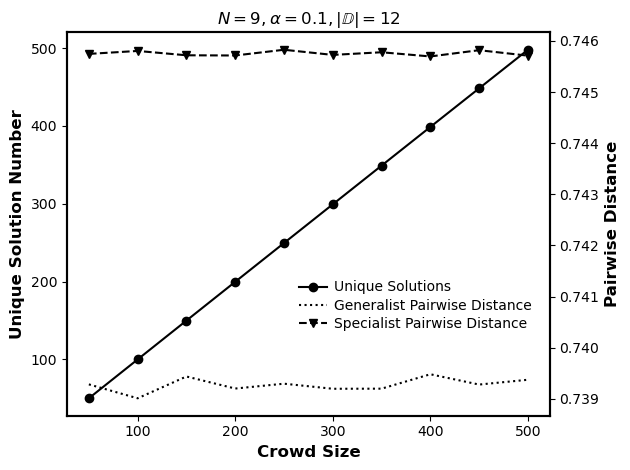

In [91]:
# Integrated Diversity Figure across Crowd Size
# Left y-axis: Unique Solution Number
# Right y-axis: Pairwise Distance
# All values are averaged across K

# -------------------------------
# Unique solution number
# -------------------------------
g_diversity_mean_across_K = []
s_diversity_mean_across_K = []

for g_diversity, s_diversity in zip(
    g_diversity_across_K_size,
    s_diversity_across_K_size
):
    g_diversity_mean_across_K.append(np.mean(g_diversity))
    s_diversity_mean_across_K.append(np.mean(s_diversity))

# Average across Generalists and Specialists to produce one single uniqueness line
diversity_mean_across_K = []
for g_mean, s_mean in zip(
    g_diversity_mean_across_K,
    s_diversity_mean_across_K
):
    diversity_mean_across_K.append(np.mean([g_mean, s_mean]))

# print("Uniqueness:", diversity_mean_across_K)


# -------------------------------
# Pairwise distance
# -------------------------------
g_pairwise_diversity_mean_across_K = []
s_pairwise_diversity_mean_across_K = []

for g_pairwise_diversity, s_pairwise_diversity in zip(
    g_pairwise_diversity_across_K_size,
    s_pairwise_diversity_across_K_size
):
    g_pairwise_diversity_mean_across_K.append(np.mean(g_pairwise_diversity))
    s_pairwise_diversity_mean_across_K.append(np.mean(s_pairwise_diversity))

# print("Generalist Pairwise Distance:", g_pairwise_diversity_mean_across_K)
# print("Specialist Pairwise Distance:", s_pairwise_diversity_mean_across_K)


# -------------------------------
# Integrated figure
# -------------------------------
x = agent_num_list

fig, ax1 = plt.subplots()

ax1.spines["left"].set_linewidth(1.5)
ax1.spines["right"].set_linewidth(1.5)
ax1.spines["top"].set_linewidth(1.5)
ax1.spines["bottom"].set_linewidth(1.5)

# Left y-axis: unique solution number
line1, = ax1.plot(
    x,
    diversity_mean_across_K,
    marker="o",
    linestyle="-",
    label="Unique Solutions",
    color="k"
)

ax1.set_xlabel("Crowd Size", fontweight="bold", fontsize=12)
ax1.set_ylabel("Unique Solution Number", fontweight="bold", fontsize=12)

# Right y-axis: pairwise distance
ax2 = ax1.twinx()

ax2.spines["left"].set_linewidth(1.5)
ax2.spines["right"].set_linewidth(1.5)
ax2.spines["top"].set_linewidth(1.5)
ax2.spines["bottom"].set_linewidth(1.5)

line2, = ax2.plot(
    x,
    g_pairwise_diversity_mean_across_K,
    marker=None,
    linestyle=":",
    label="Generalist Pairwise Distance",
    color="k"
)

line3, = ax2.plot(
    x,
    s_pairwise_diversity_mean_across_K,
    marker="v",
    linestyle="--",
    label="Specialist Pairwise Distance",
    color="k"
)

ax2.set_ylabel("Pairwise Distance", fontweight="bold", fontsize=12)

plt.title(r"$N=9, \alpha=0.1, |\mathbb{D}|=12$")

# Combine legends from both y-axes
lines = [line1, line2, line3]
labels = [line.get_label() for line in lines]

ax1.legend(
    lines,
    labels,
    frameon=False,
    ncol=1,
    fontsize=10,
    loc="lower right",
    bbox_to_anchor=(0.98, 0.2),
    handlelength=2.0,
    handletextpad=0.5,
    labelspacing=0.3,
    borderaxespad=0.2
)

fig.tight_layout()

plt.savefig(
    results_folder / "parallel_search_integrated_diversity_across_size",
    transparent=True,
    dpi=300
)

plt.show()